# MDCE Bias and Leakage Guard Add-on

This notebook does not rerun ingestion. It starts from `pit_training_rows.parquet` and audits whether the model is relying too much on shortcut signals such as lap/progress timing, driver/circuit identity, or tyre signals.

Important: this is not about making the model look better. It is about making the proof layer more honest.


## 1. Mount Drive


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## 2. Install Dependencies


In [2]:
%pip install -q pandas numpy pyarrow scikit-learn matplotlib seaborn joblib


## 3. Run Bias Guard Audit

This trains multiple feature-set variants. Thresholds are selected on 2022 validation only, then evaluated on untouched 2023 holdout.


In [3]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


ROOT = Path("/content/drive/MyDrive/ibm_project_stuff/MDCE")
if not ROOT.exists():
    raise FileNotFoundError(
        f"Expected project folder not found: {ROOT}. "
        "This add-on is folder-locked and will not scan MyDrive."
    )

PROCESSED_DIR = ROOT / "data" / "processed"
REPORT_DIR = ROOT / "outputs" / "reports"
CHART_DIR = ROOT / "outputs" / "charts"
MODEL_DIR = ROOT / "outputs" / "models"

for folder in [REPORT_DIR, CHART_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

training_path = PROCESSED_DIR / "pit_training_rows.parquet"
training = pd.read_parquet(training_path)
print("training shape:", training.shape)

target = "pit_within_3_laps"
numeric_features = [
    "lap",
    "lap_time_s",
    "position",
    "grid",
    "tyre_age",
    "stint",
    "air_temp",
    "track_temp",
    "humidity",
    "pressure",
    "rainfall",
    "wind_speed",
    "wind_direction",
    "rolling_lap_avg_3",
    "rolling_lap_avg_5",
    "lap_time_delta",
    "degradation_3",
    "degradation_5",
    "lap_progress_ratio",
]
categorical_features = ["tyre_compound", "driver_code", "circuit"]
all_features = numeric_features + categorical_features

required_cols = all_features + [target, "year", "raceId", "driverId"]
missing = [col for col in required_cols if col not in training.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

train_2021 = training[training["year"].eq(2021)].dropna(subset=[target]).copy()
valid_2022 = training[training["year"].eq(2022)].dropna(subset=[target]).copy()
train_2021_2022 = training[training["year"].isin([2021, 2022])].dropna(subset=[target]).copy()
test_2023 = training[training["year"].eq(2023)].dropna(subset=[target]).copy()

print("train_2021:", train_2021.shape, "valid_2022:", valid_2022.shape, "test_2023:", test_2023.shape)


def write_json(path, data):
    Path(path).write_text(json.dumps(data, indent=2, default=str), encoding="utf-8")
    print("wrote:", path)


def build_model(feature_list):
    numeric = [col for col in feature_list if col in numeric_features]
    categorical = [col for col in feature_list if col in categorical_features]
    return Pipeline(
        steps=[
            (
                "preprocess",
                ColumnTransformer(
                    transformers=[
                        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric),
                        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical),
                    ]
                ),
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=250,
                    min_samples_leaf=3,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def evaluate(y_true, scores, threshold):
    labels = (scores >= threshold).astype(int)
    row = {
        "threshold": float(threshold),
        "rows": int(len(y_true)),
        "positive_rate": float(np.mean(y_true)),
        "predicted_positive_rate": float(np.mean(labels)),
        "accuracy": float(accuracy_score(y_true, labels)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, labels)),
        "precision": float(precision_score(y_true, labels, zero_division=0)),
        "recall": float(recall_score(y_true, labels, zero_division=0)),
        "f1": float(f1_score(y_true, labels, zero_division=0)),
        "brier_score": float(brier_score_loss(y_true, scores)),
        "roc_auc": float(roc_auc_score(y_true, scores)) if len(set(y_true)) == 2 else None,
        "average_precision": float(average_precision_score(y_true, scores)) if len(set(y_true)) == 2 else None,
    }
    return row


def choose_threshold_on_validation(scores, y_true):
    rows = []
    for threshold in np.round(np.arange(0.10, 0.91, 0.05), 2):
        row = evaluate(y_true, scores, float(threshold))
        rows.append(row)
    sweep = pd.DataFrame(rows)
    best = sweep.sort_values(["f1", "precision"], ascending=False).iloc[0].to_dict()
    return best, sweep


feature_sets = {
    "full_state_context": all_features,
    "no_schedule_progress": [col for col in all_features if col not in ["lap", "lap_progress_ratio"]],
    "no_identity_context": [col for col in all_features if col not in ["driver_code", "circuit"]],
    "state_only_no_schedule_no_identity": [
        col for col in all_features if col not in ["lap", "lap_progress_ratio", "driver_code", "circuit"]
    ],
    "no_tyre_signals": [col for col in all_features if col not in ["tyre_age", "tyre_compound", "stint"]],
    "degradation_weather_tyre_only": [
        "lap_time_s",
        "tyre_age",
        "stint",
        "air_temp",
        "track_temp",
        "humidity",
        "pressure",
        "rainfall",
        "wind_speed",
        "wind_direction",
        "rolling_lap_avg_3",
        "rolling_lap_avg_5",
        "lap_time_delta",
        "degradation_3",
        "degradation_5",
        "tyre_compound",
    ],
}

print("\nSTEP A: threshold-from-validation feature-set audit")
audit_rows = []
threshold_rows = []
trained_models = {}

for set_name, features in feature_sets.items():
    print("auditing feature set:", set_name, "features:", len(features))

    validation_model = build_model(features)
    validation_model.fit(train_2021[features], train_2021[target].astype(int))
    validation_scores = validation_model.predict_proba(valid_2022[features])[:, 1]
    best_threshold, sweep = choose_threshold_on_validation(validation_scores, valid_2022[target].astype(int).to_numpy())
    sweep["feature_set"] = set_name
    threshold_rows.append(sweep)

    final_model = build_model(features)
    final_model.fit(train_2021_2022[features], train_2021_2022[target].astype(int))
    test_scores = final_model.predict_proba(test_2023[features])[:, 1]

    test_at_validation_threshold = evaluate(test_2023[target].astype(int).to_numpy(), test_scores, best_threshold["threshold"])
    test_at_validation_threshold.update(
        {
            "feature_set": set_name,
            "feature_count": len(features),
            "threshold_source": "best_f1_on_2022_validation",
            "selected_threshold": best_threshold["threshold"],
            "validation_f1_at_selected_threshold": best_threshold["f1"],
            "validation_precision_at_selected_threshold": best_threshold["precision"],
            "validation_recall_at_selected_threshold": best_threshold["recall"],
        }
    )
    audit_rows.append(test_at_validation_threshold)

    test_at_050 = evaluate(test_2023[target].astype(int).to_numpy(), test_scores, 0.50)
    test_at_050.update(
        {
            "feature_set": set_name,
            "feature_count": len(features),
            "threshold_source": "fixed_0_50",
            "selected_threshold": 0.50,
            "validation_f1_at_selected_threshold": None,
            "validation_precision_at_selected_threshold": None,
            "validation_recall_at_selected_threshold": None,
        }
    )
    audit_rows.append(test_at_050)

    trained_models[set_name] = {"model": final_model, "features": features, "scores": test_scores, "threshold": best_threshold["threshold"]}

audit_df = pd.DataFrame(audit_rows).sort_values(["threshold_source", "average_precision", "f1"], ascending=[True, False, False])
threshold_df = pd.concat(threshold_rows, ignore_index=True)

audit_df.to_csv(REPORT_DIR / "bias_guard_feature_set_audit.csv", index=False)
threshold_df.to_csv(REPORT_DIR / "bias_guard_validation_threshold_sweeps.csv", index=False)

best_validation_threshold_row = audit_df[audit_df["threshold_source"].eq("best_f1_on_2022_validation")].sort_values(
    ["average_precision", "f1"], ascending=False
).iloc[0]
best_feature_set = str(best_validation_threshold_row["feature_set"])
joblib.dump(trained_models[best_feature_set]["model"], MODEL_DIR / "pit_window_bias_guard_best_model.joblib")
print("best bias-guard feature set:", best_feature_set)
print(audit_df.to_string(index=False))

plt.figure(figsize=(11, 6))
plot_df = audit_df[audit_df["threshold_source"].eq("best_f1_on_2022_validation")].copy()
plot_df = plot_df.sort_values("average_precision", ascending=True)
plt.barh(plot_df["feature_set"], plot_df["average_precision"])
plt.title("Bias Guard: 2023 Average Precision By Feature Set")
plt.xlabel("Average precision")
plt.tight_layout()
plt.savefig(CHART_DIR / "bias_guard_feature_set_ap.png", dpi=160)
plt.close()

plt.figure(figsize=(11, 6))
plot_f1 = audit_df[audit_df["threshold_source"].eq("best_f1_on_2022_validation")].sort_values("f1", ascending=True)
plt.barh(plot_f1["feature_set"], plot_f1["f1"])
plt.title("Bias Guard: 2023 F1 By Feature Set")
plt.xlabel("F1")
plt.tight_layout()
plt.savefig(CHART_DIR / "bias_guard_feature_set_f1.png", dpi=160)
plt.close()

print("\nSTEP B: group weak-spot audit for best feature set")
best_info = trained_models[best_feature_set]
test_scores = best_info["scores"]
threshold = best_info["threshold"]
test_labels = (test_scores >= threshold).astype(int)
group_eval = test_2023[["raceId", "driverId", "driver_code", "circuit", target]].copy()
group_eval["score"] = test_scores
group_eval["prediction"] = test_labels


def group_metrics(df, group_col, min_rows=100):
    rows = []
    for group_value, part in df.groupby(group_col):
        if len(part) < min_rows or len(set(part[target])) < 2:
            continue
        row = evaluate(part[target].astype(int).to_numpy(), part["score"].to_numpy(), threshold)
        row[group_col] = group_value
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["f1", "average_precision"], ascending=True)


circuit_metrics = group_metrics(group_eval, "circuit", min_rows=150)
driver_metrics = group_metrics(group_eval, "driver_code", min_rows=150)
circuit_metrics.to_csv(REPORT_DIR / "bias_guard_circuit_classification_metrics.csv", index=False)
driver_metrics.to_csv(REPORT_DIR / "bias_guard_driver_classification_metrics.csv", index=False)

if not circuit_metrics.empty:
    plt.figure(figsize=(10, 6))
    plot_circuit = circuit_metrics.head(15).sort_values("f1", ascending=True)
    plt.barh(plot_circuit["circuit"], plot_circuit["f1"])
    plt.title("Bias Guard: Lowest Circuit F1 Scores")
    plt.xlabel("F1")
    plt.tight_layout()
    plt.savefig(CHART_DIR / "bias_guard_lowest_circuit_f1.png", dpi=160)
    plt.close()

print("\nSTEP C: write bias guard report")

full_ap = float(
    audit_df[
        audit_df["feature_set"].eq("full_state_context")
        & audit_df["threshold_source"].eq("best_f1_on_2022_validation")
    ]["average_precision"].iloc[0]
)
no_schedule_ap = float(
    audit_df[
        audit_df["feature_set"].eq("no_schedule_progress")
        & audit_df["threshold_source"].eq("best_f1_on_2022_validation")
    ]["average_precision"].iloc[0]
)
schedule_dependency_gap = full_ap - no_schedule_ap

guard = {
    "best_feature_set": best_feature_set,
    "best_model_path": str(MODEL_DIR / "pit_window_bias_guard_best_model.joblib"),
    "threshold_selection_rule": "Threshold selected on 2022 validation only, then evaluated on untouched 2023 holdout.",
    "full_vs_no_schedule_average_precision_gap": schedule_dependency_gap,
    "feature_set_audit": audit_df.to_dict(orient="records"),
    "circuit_weak_spots": circuit_metrics.head(15).to_dict(orient="records") if not circuit_metrics.empty else [],
    "driver_weak_spots": driver_metrics.head(15).to_dict(orient="records") if not driver_metrics.empty else [],
    "interpretation": [
        "If no_schedule_progress drops sharply, the model relies heavily on race phase timing.",
        "This is not automatically leakage because lap and tyre age are known at decision time, but it means the model may learn typical strategy windows.",
        "A strong proof layer should report this dependency instead of hiding it.",
        "Thresholds are selected on 2022 validation, not on the 2023 test set, to avoid test-set threshold bias.",
    ],
}
write_json(REPORT_DIR / "bias_guard_audit.json", guard)

lines = [
    "# MDCE Bias and Leakage Guard Audit",
    "",
    "## Purpose",
    "",
    "This audit checks whether the pit-window model is relying too heavily on race-phase timing, driver/circuit identity, or other shortcut signals.",
    "",
    "## Best Bias-Guard Model",
    "",
    f"- Feature set: `{best_feature_set}`",
    f"- Model path: `{MODEL_DIR / 'pit_window_bias_guard_best_model.joblib'}`",
    f"- Threshold selection: `{guard['threshold_selection_rule']}`",
    "",
    "## Schedule Dependency Check",
    "",
    f"- Full feature AP: `{full_ap:.3f}`",
    f"- No schedule/progress AP: `{no_schedule_ap:.3f}`",
    f"- AP gap: `{schedule_dependency_gap:.3f}`",
    "",
    "Interpretation: a large positive gap means the model gets meaningful signal from lap/progress timing. That is allowed because lap is known at decision time, but it must be disclosed because it can reflect typical strategy-window learning.",
    "",
    "## Feature Set Audit",
    "",
    "| Feature Set | Threshold Source | Threshold | AP | ROC-AUC | F1 | Precision | Recall |",
    "|---|---|---:|---:|---:|---:|---:|---:|",
]
for _, row in audit_df.iterrows():
    lines.append(
        f"| {row['feature_set']} | {row['threshold_source']} | {row['selected_threshold']:.2f} | {row['average_precision']:.3f} | {row['roc_auc']:.3f} | {row['f1']:.3f} | {row['precision']:.3f} | {row['recall']:.3f} |"
    )

lines += [
    "",
    "## Worst Circuit Classification Groups",
    "",
]
if circuit_metrics.empty:
    lines.append("- Not enough circuit rows to compute grouped circuit metrics.")
else:
    for _, row in circuit_metrics.head(10).iterrows():
        lines.append(f"- `{row['circuit']}`: F1 `{row['f1']:.3f}`, AP `{row['average_precision']:.3f}`, rows `{int(row['rows'])}`")

lines += [
    "",
    "## Files Written",
    "",
    f"- `{REPORT_DIR / 'bias_guard_feature_set_audit.csv'}`",
    f"- `{REPORT_DIR / 'bias_guard_validation_threshold_sweeps.csv'}`",
    f"- `{REPORT_DIR / 'bias_guard_circuit_classification_metrics.csv'}`",
    f"- `{REPORT_DIR / 'bias_guard_driver_classification_metrics.csv'}`",
    f"- `{REPORT_DIR / 'bias_guard_audit.json'}`",
    f"- `{CHART_DIR / 'bias_guard_feature_set_ap.png'}`",
    f"- `{CHART_DIR / 'bias_guard_feature_set_f1.png'}`",
    f"- `{CHART_DIR / 'bias_guard_lowest_circuit_f1.png'}`",
]
(REPORT_DIR / "bias_guard_audit.md").write_text("\n".join(lines), encoding="utf-8")

print("\nBIAS GUARD COMPLETE")
print("Best feature set:", best_feature_set)
print("Schedule dependency AP gap:", round(schedule_dependency_gap, 4))
print("Report:", REPORT_DIR / "bias_guard_audit.md")


training shape: (40867, 32)
train_2021: (13766, 32) valid_2022: (12417, 32) test_2023: (14684, 32)

STEP A: threshold-from-validation feature-set audit
auditing feature set: full_state_context features: 22
auditing feature set: no_schedule_progress features: 20
auditing feature set: no_identity_context features: 20
auditing feature set: state_only_no_schedule_no_identity features: 18
auditing feature set: no_tyre_signals features: 19
auditing feature set: degradation_weather_tyre_only features: 16
best bias-guard feature set: no_identity_context
 threshold  rows  positive_rate  predicted_positive_rate  accuracy  balanced_accuracy  precision   recall       f1  brier_score  roc_auc  average_precision                        feature_set  feature_count           threshold_source  selected_threshold  validation_f1_at_selected_threshold  validation_precision_at_selected_threshold  validation_recall_at_selected_threshold
      0.40 14684        0.22167                 0.185849  0.887633       

## 4. View Outputs


Bias-guard model: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/pit_window_bias_guard_best_model.joblib


# MDCE Bias and Leakage Guard Audit

## Purpose

This audit checks whether the pit-window model is relying too heavily on race-phase timing, driver/circuit identity, or other shortcut signals.

## Best Bias-Guard Model

- Feature set: `no_identity_context`
- Model path: `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/pit_window_bias_guard_best_model.joblib`
- Threshold selection: `Threshold selected on 2022 validation only, then evaluated on untouched 2023 holdout.`

## Schedule Dependency Check

- Full feature AP: `0.813`
- No schedule/progress AP: `0.602`
- AP gap: `0.211`

Interpretation: a large positive gap means the model gets meaningful signal from lap/progress timing. That is allowed because lap is known at decision time, but it must be disclosed because it can reflect typical strategy-window learning.

## Feature Set Audit

| Feature Set | Threshold Source | Threshold | AP | ROC-AUC | F1 | Precision | Recall |
|---|---|---:|---:|---:|---:|---:|---:|
| no_identity_context | best_f1_on_2022_validation | 0.40 | 0.818 | 0.893 | 0.724 | 0.794 | 0.666 |
| full_state_context | best_f1_on_2022_validation | 0.40 | 0.813 | 0.888 | 0.721 | 0.763 | 0.683 |
| no_tyre_signals | best_f1_on_2022_validation | 0.50 | 0.788 | 0.860 | 0.699 | 0.896 | 0.572 |
| no_schedule_progress | best_f1_on_2022_validation | 0.35 | 0.602 | 0.795 | 0.540 | 0.435 | 0.711 |
| state_only_no_schedule_no_identity | best_f1_on_2022_validation | 0.35 | 0.594 | 0.795 | 0.539 | 0.450 | 0.673 |
| degradation_weather_tyre_only | best_f1_on_2022_validation | 0.35 | 0.585 | 0.789 | 0.539 | 0.442 | 0.692 |
| no_identity_context | fixed_0_50 | 0.50 | 0.818 | 0.893 | 0.724 | 0.885 | 0.612 |
| full_state_context | fixed_0_50 | 0.50 | 0.813 | 0.888 | 0.719 | 0.868 | 0.614 |
| no_tyre_signals | fixed_0_50 | 0.50 | 0.788 | 0.860 | 0.699 | 0.896 | 0.572 |
| no_schedule_progress | fixed_0_50 | 0.50 | 0.602 | 0.795 | 0.516 | 0.557 | 0.482 |
| state_only_no_schedule_no_identity | fixed_0_50 | 0.50 | 0.594 | 0.795 | 0.506 | 0.545 | 0.471 |
| degradation_weather_tyre_only | fixed_0_50 | 0.50 | 0.585 | 0.789 | 0.504 | 0.527 | 0.483 |

## Worst Circuit Classification Groups

- `Circuit Park Zandvoort`: F1 `0.578`, AP `0.683`, rows `1162`
- `Silverstone Circuit`: F1 `0.631`, AP `0.881`, rows `562`
- `Red Bull Ring`: F1 `0.639`, AP `0.780`, rows `845`
- `Albert Park Grand Prix Circuit`: F1 `0.656`, AP `0.706`, rows `920`
- `Losail International Circuit`: F1 `0.672`, AP `0.829`, rows `762`
- `Autódromo José Carlos Pace`: F1 `0.688`, AP `0.838`, rows `784`
- `Circuit de Spa-Francorchamps`: F1 `0.696`, AP `0.827`, rows `483`
- `Suzuka Circuit`: F1 `0.700`, AP `0.806`, rows `545`
- `Circuit Gilles Villeneuve`: F1 `0.703`, AP `0.791`, rows `696`
- `Circuit de Monaco`: F1 `0.714`, AP `0.828`, rows `1093`

## Files Written

- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/bias_guard_feature_set_audit.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/bias_guard_validation_threshold_sweeps.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/bias_guard_circuit_classification_metrics.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/bias_guard_driver_classification_metrics.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/bias_guard_audit.json`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/bias_guard_feature_set_ap.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/bias_guard_feature_set_f1.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/bias_guard_lowest_circuit_f1.png`

 bias_guard_feature_set_audit.csv


,threshold,rows,positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,brier_score,roc_auc,average_precision,feature_set,feature_count,threshold_source,selected_threshold,validation_f1_at_selected_threshold,validation_precision_at_selected_threshold,validation_recall_at_selected_threshold
0,0.40,14684,0.22167,0.185849,0.887633,0.808286,0.794064,0.665745,0.724265,0.085313,0.893129,0.817652,no_identity_context,20,best_f1_on_2022_validation,0.40,0.692591,0.703745,0.681785
1,0.40,14684,0.22167,0.198515,0.882593,0.811201,0.762607,0.682949,0.720583,0.090487,0.888453,0.812555,full_state_context,22,best_f1_on_2022_validation,0.40,0.694490,0.700776,0.688316
2,0.50,14684,0.22167,0.141583,0.890493,0.776725,0.896104,0.572350,0.698538,0.093996,0.859933,0.788424,no_tyre_signals,19,best_f1_on_2022_validation,0.50,0.669232,0.814680,0.567852
3,0.35,14684,0.22167,0.362095,0.731408,0.724077,0.435208,0.710906,0.539897,0.140954,0.794753,0.602007,no_schedule_progress,20,best_f1_on_2022_validation,0.35,0.524335,0.429731,0.672351
4,0.35,14684,0.22167,0.331926,0.744824,0.719182,0.449528,0.673118,0.539058,0.139059,0.794601,0.593614,state_only_no_schedule_no_identity,18,best_f1_on_2022_validation,0.35,0.528129,0.455430,0.628447
5,0.35,14684,0.22167,0.346772,0.738150,0.721487,0.442066,0.691551,0.539355,0.142415,0.788994,0.584741,degradation_weather_tyre_only,16,best_f1_on_2022_validation,0.35,0.524639,0.447692,0.633527
6,0.50,14684,0.22167,0.153296,0.896486,0.794857,0.885384,0.612289,0.723938,0.085313,0.893129,0.817652,no_identity_context,20,fixed_0_50,0.50,NaN,NaN,NaN
7,0.50,14684,0.22167,0.156837,0.893762,0.793767,0.867998,0.614132,0.719323,0.090487,0.888453,0.812555,full_state_context,22,fixed_0_50,0.50,NaN,NaN,NaN
8,0.50,14684,0.22167,0.141583,0.890493,0.776725,0.896104,0.572350,0.698538,0.093996,0.859933,0.788424,no_tyre_signals,19,fixed_0_50,0.50,NaN,NaN,NaN
9,0.50,14684,0.22167,0.191841,0.800054,0.686219,0.556621,0.481720,0.516469,0.140954,0.794753,0.602007,no_schedule_progress,20,fixed_0_50,0.50,NaN,NaN,NaN


 bias_guard_validation_threshold_sweeps.csv


...

 bias_guard_circuit_classification_metrics.csv


,threshold,rows,positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,brier_score,roc_auc,average_precision,circuit
0,0.4,1162,0.273666,0.164372,0.814974,0.705066,0.769634,0.462264,0.577603,0.143464,0.747235,0.683200,Circuit Park Zandvoort
1,0.4,562,0.169039,0.293594,0.829181,0.842714,0.496970,0.863158,0.630769,0.087823,0.926519,0.880784,Silverstone Circuit
2,0.4,845,0.241420,0.128994,0.866272,0.738078,0.917431,0.490196,0.638978,0.108619,0.860351,0.780488,Red Bull Ring
3,0.4,920,0.201087,0.133696,0.884783,0.758007,0.821138,0.545946,0.655844,0.106029,0.762508,0.706136,Albert Park Grand Prix Circuit
4,0.4,762,0.274278,0.178478,0.851706,0.759429,0.852941,0.555024,0.672464,0.101384,0.906435,0.828700,Losail International Circuit
5,0.4,784,0.211735,0.155612,0.885204,0.779584,0.811475,0.596386,0.687500,0.079731,0.926882,0.838350,Autódromo José Carlos Pace
6,0.4,483,0.306418,0.265010,0.826087,0.776563,0.750000,0.648649,0.695652,0.115939,0.863534,0.826557,Circuit de Spa-Francorchamps
7,0.4,545,0.273394,0.313761,0.823853,0.801344,0.654971,0.751678,0.700000,0.115641,0.880601,0.806394,Suzuka Circuit
8,0.4,696,0.185345,0.186782,0.889368,0.818322,0.700000,0.705426,0.702703,0.081780,0.886059,0.790765,Circuit Gilles Villeneuve
9,0.4,1093,0.123513,0.135407,0.925892,0.849544,0.682432,0.748148,0.713781,0.061912,0.932104,0.827722,Circuit de Monaco


 bias_guard_driver_classification_metrics.csv


,threshold,rows,positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,brier_score,roc_auc,average_precision,driver_code
0,0.4,763,0.242464,0.188729,0.846658,0.753615,0.736111,0.572973,0.644377,0.104190,0.855831,0.772079,NOR
1,0.4,181,0.292818,0.182320,0.845304,0.757960,0.878788,0.547170,0.674419,0.117133,0.878833,0.813121,LAW
2,0.4,761,0.236531,0.172142,0.872536,0.776568,0.816794,0.594444,0.688103,0.095763,0.875120,0.794373,ZHO
3,0.4,753,0.219124,0.216467,0.864542,0.799907,0.693252,0.684848,0.689024,0.088602,0.898134,0.809633,RUS
4,0.4,324,0.206790,0.212963,0.870370,0.807945,0.681159,0.701493,0.691176,0.084998,0.895813,0.817663,DEV
5,0.4,904,0.190265,0.206858,0.879425,0.821022,0.668449,0.726744,0.696379,0.077402,0.912672,0.832549,VER
6,0.4,235,0.229787,0.195745,0.872340,0.793687,0.760870,0.648148,0.700000,0.098492,0.858400,0.785760,RIC
7,0.4,681,0.217327,0.154185,0.889868,0.785666,0.847619,0.601351,0.703557,0.083731,0.889166,0.808745,PIA
8,0.4,742,0.216981,0.171159,0.889488,0.799222,0.811024,0.639752,0.715278,0.088523,0.875595,0.788213,TSU
9,0.4,641,0.241810,0.174727,0.882995,0.793217,0.857143,0.619355,0.719101,0.094063,0.886911,0.813524,MAG


Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/bias_guard_feature_set_ap.png


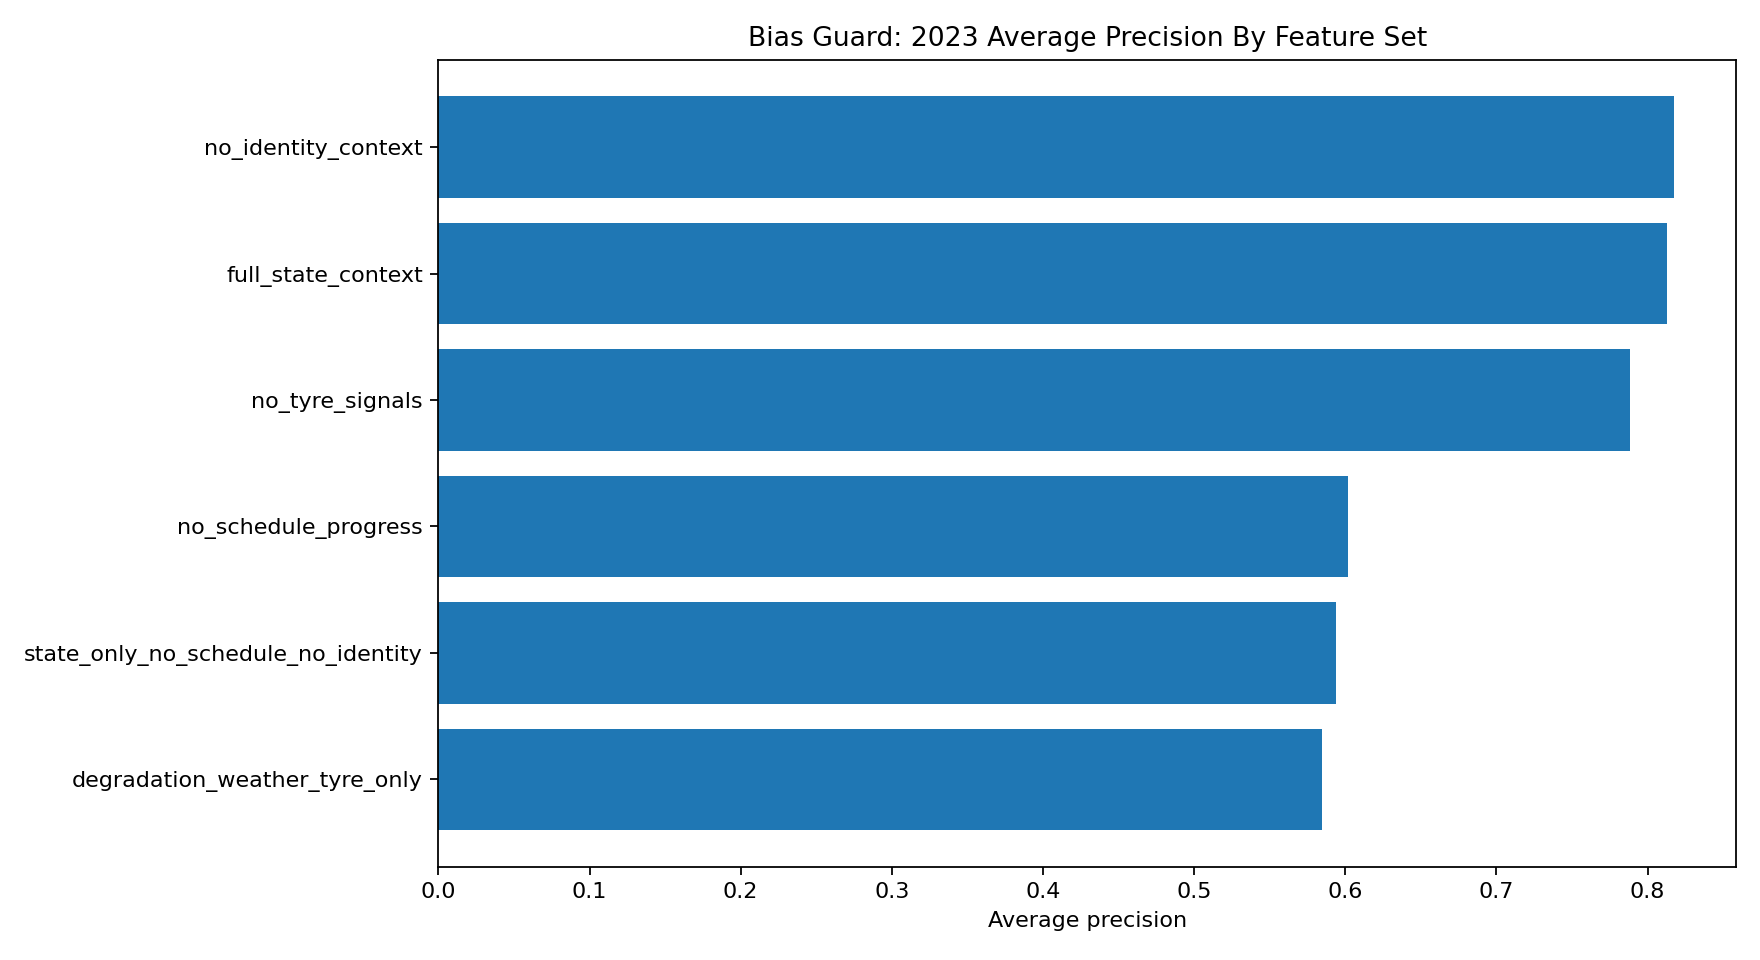

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/bias_guard_feature_set_f1.png


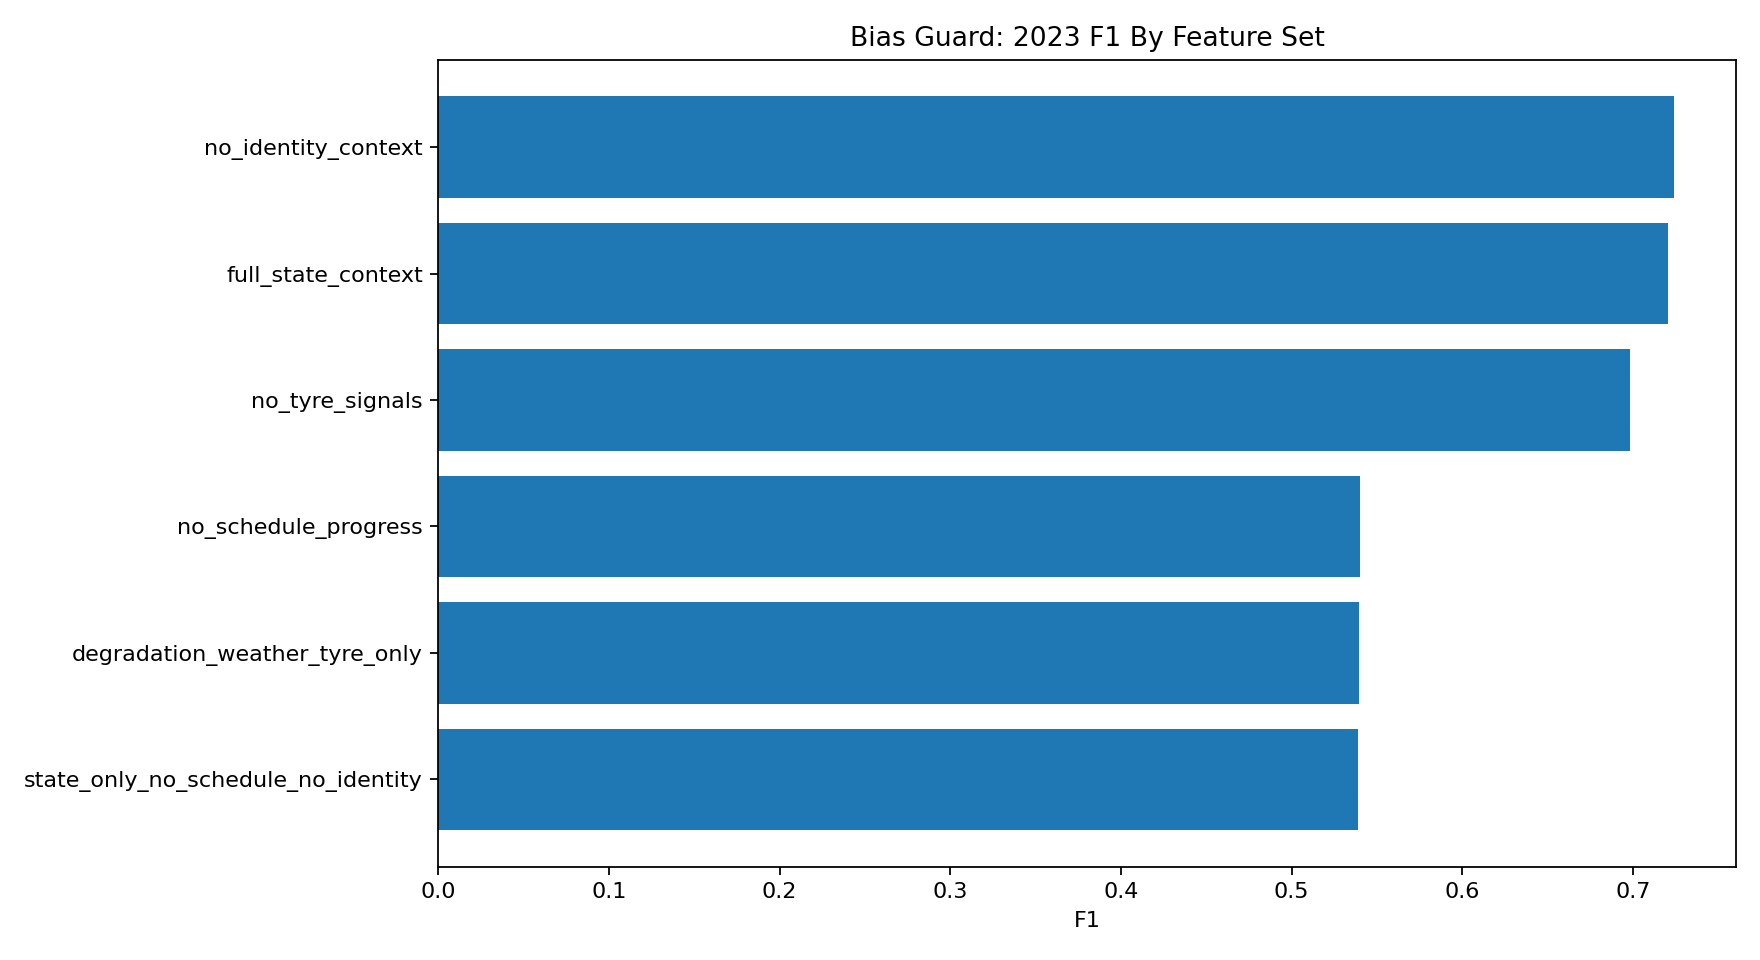

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/bias_guard_lowest_circuit_f1.png


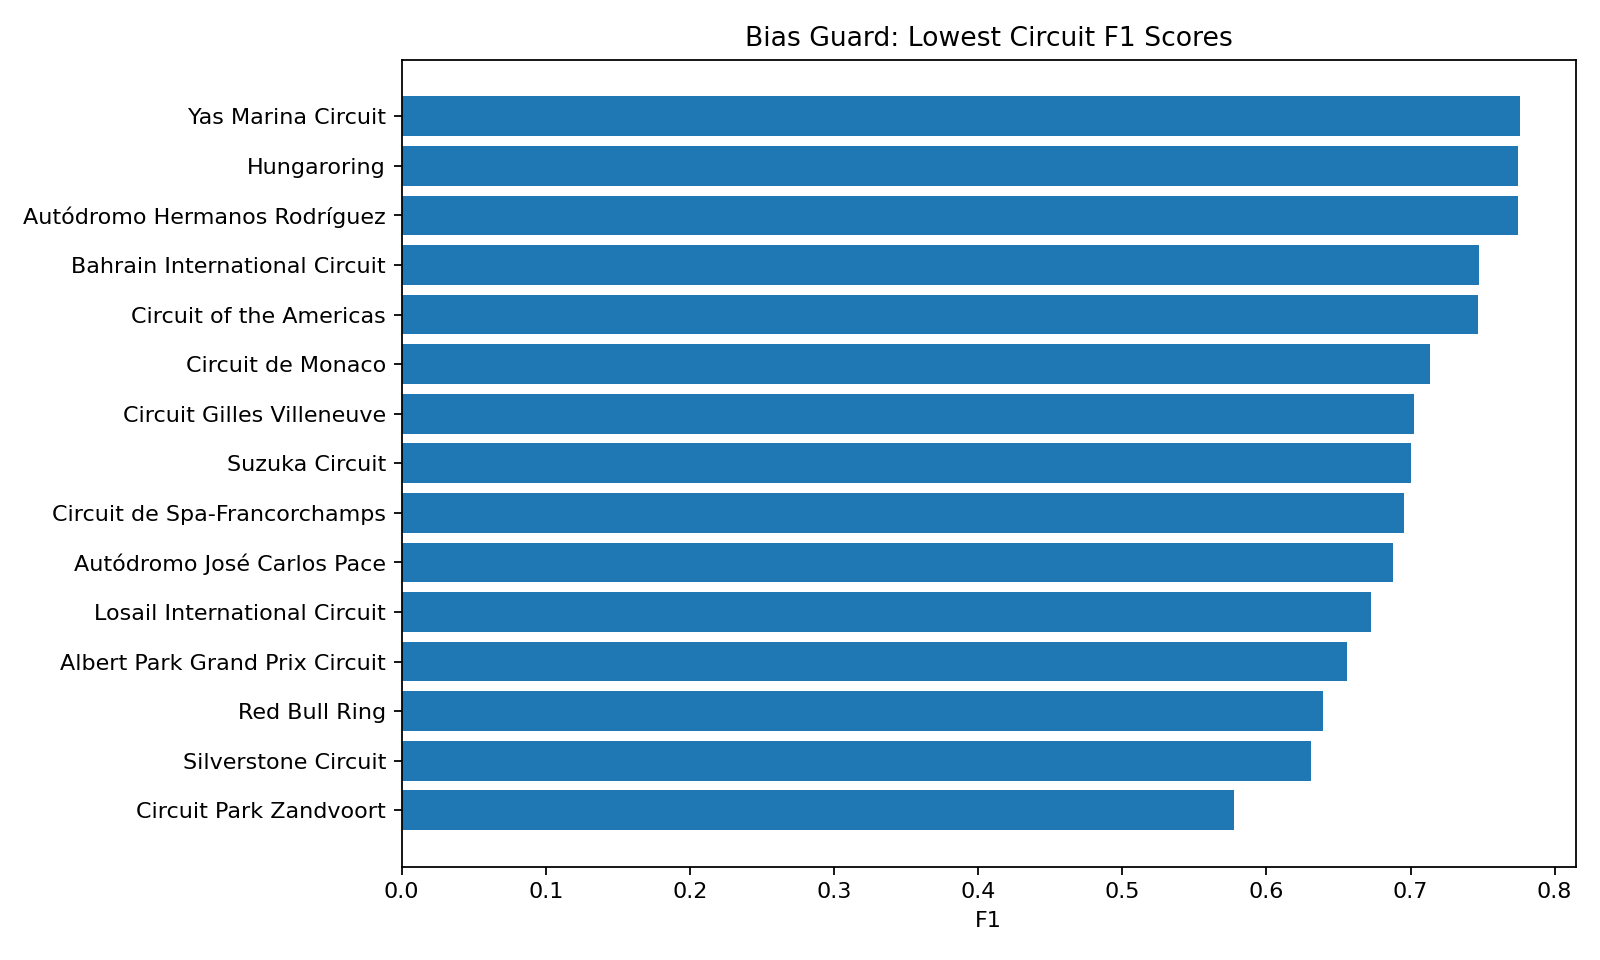

In [4]:
from pathlib import Path
from IPython.display import Markdown, Image, display
import pandas as pd

ROOT = Path('/content/drive/MyDrive/ibm_project_stuff/MDCE')
REPORT_DIR = ROOT / 'outputs' / 'reports'
CHART_DIR = ROOT / 'outputs' / 'charts'
MODEL_DIR = ROOT / 'outputs' / 'models'

print('Bias-guard model:', MODEL_DIR / 'pit_window_bias_guard_best_model.joblib')
report = REPORT_DIR / 'bias_guard_audit.md'
if report.exists():
    display(Markdown(report.read_text(encoding='utf-8')))

for csv_name in [
    'bias_guard_feature_set_audit.csv',
    'bias_guard_validation_threshold_sweeps.csv',
    'bias_guard_circuit_classification_metrics.csv',
    'bias_guard_driver_classification_metrics.csv',
]:
    path = REPORT_DIR / csv_name
    if path.exists():
        print('', csv_name)
        display(pd.read_csv(path).head(30))

for chart_name in [
    'bias_guard_feature_set_ap.png',
    'bias_guard_feature_set_f1.png',
    'bias_guard_lowest_circuit_f1.png',
]:
    path = CHART_DIR / chart_name
    if path.exists():
        print('Chart:', path)
        display(Image(filename=str(path)))
